In [1]:
import os
# Force Hugging Face libraries to stay offline
os.environ['HF_DATASETS_OFFLINE'] = '1'
os.environ['HF_EVALUATE_OFFLINE'] = '1'
os.environ['TRANSFORMERS_OFFLINE'] = '1'

In [2]:
import torch
import faiss
import numpy as np
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from transformers import AutoModelForCausalLM
from diffusers import DDPMScheduler # Useful for the CMD denoising logic

# Metrics for evaluating reconstruction fidelity
from evaluate import load
bleu = load("bleu")
rouge = load("rouge")


/home/pmd4nd/.conda/envs/privacy_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using the latest cached version of the module from /home/pmd4nd/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--bleu/9e0985c1200e367cce45605ce0ecb5ede079894e0f24f54613fca08eeb8aff76 (last modified on Thu Mar  5 12:14:48 2026) since it couldn't be found locally at evaluate-metric--bleu, or remotely on the Hugging Face Hub.
Using the latest cached version of the module from /home/pmd4nd/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--rouge/6e5315f72865c2eaa764c8361360bb938740b9c120a2cf3a7ad218aa0ce452ed (last modified on Thu Mar  5 12:14:52 2026) since it couldn't be found locally at evaluate-metric--rouge, or remotely on the Hugging Face Hub.


# Phase 2: Cold-Start Optimization and Conditional Masked Diffusion Attacks

**Goal**: Establish a vulnerability baseline before implementing differential privacy. Think of this like a "stress test" for our data. Before we apply a defense like Differential Privacy (DP) — which will inevitably make our search results a bit less accurate (the "Utility Cost") — we first need to prove that an attack is actually possible and dangerous on our current setup.

**The Two Paradigms of our Attack Phase**: We are essentially testing two different generations of attacks to see which one leaks more PII:

1. **Vec2Text (The Iterative Correction Baseline)**
This is a "feedback-loop" attack. It guesses some text, checks how close the embedding is to the target, and nudges the words until they match.

    The Goal: Prove that high-dimensional vectors ($v \in \mathbb{R}^{768}$) aren't "hashes" and can be reversed through simple optimization.

    Success Metric: If we get a high BLEU score here, we've proven the "Standard" RAG pipeline is unsafe for PII.

2. **CMD (Conditional Masked Diffusion)**
This is the "state-of-the-art" method from the Feb 2026 paper you found. Instead of a slow loop, it uses a diffusion process to "denoise" the entire 32-token sequence at once, using the embedding as a guide.

    The Goal: Show that even if an attacker doesn't have the time for a 50-round Vec2Text loop, they can still "reveal" the text in just a few parallel steps.


Why "Before DP" is Crucial
In research, this is called the "Unprotected Setting." By measuring the Exact Match (EM) and ROUGE-L scores now, we create the "Top" of your graph.

Later, in Phase 3, we will add Laplace Noise (DP) to our FAISS vectors. We will then run these exact same attacks again. The "Gap" between the Phase 2 scores and the Phase 3 scores is our Privacy Gain.

In [3]:
import pickle

# Run this if you already have the processed file
if os.path.exists("processed_pii_texts.pkl"):
    with open("processed_pii_texts.pkl", "rb") as f:
        texts_for_db = pickle.load(f)
    print(f"Ready! Loaded {len(texts_for_db)} pre-processed PII samples.")

Ready! Loaded 43000 pre-processed PII samples.


In [4]:
# Load the FAISS index (the vectors) if saved
if os.path.exists("pii_audit_target.index"):
    index = faiss.read_index("pii_audit_target.index")
    print(f"Index loaded. Total vectors: {index.ntotal}")

Index loaded. Total vectors: 43000


In [5]:
vectors = np.load("embeddings.npy")

### Initialize Model

In [6]:
from transformers import AutoTokenizer, T5EncoderModel

device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_LOCAL_PATH = "./gtr-t5-base-local"

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_LOCAL_PATH)

# Load encoder-only model
model = T5EncoderModel.from_pretrained(MODEL_LOCAL_PATH)
model.to(device)
model.eval()

print("GTR-T5 Model successfully initialized")

Loading weights: 100%|██████████| 99/99 [00:00<00:00, 21435.97it/s]

GTR-T5 Model successfully initialized


### Cold-Start Optimization Baseline

In this scenario, we assume the attacker has found a 768-dimensional vector $v$ in our FAISS index and knows we used the GTR-T5 model. The attacker's goal is to find a string of 32 tokens that, when embedded, produces a vector as close to $v$ as possible.

#### The "Cold-Start" Logic
Since we can't easily do gradient descent on discrete words, we optimize the continuous input embeddings instead.

1. Pick a Target: We select a "victim" vector from your FAISS index.

2. Initialize Guess: We start with a random 768-d tensor (or the embedding of 32 [MASK] tokens).

3. The Loop:

    * Pass the "guess" through the GTR-T5 encoder.

    * Calculate the L2 Loss between the resulting vector and the victim vector.

    * Use an optimizer (Adam) to update the "guess" to reduce that loss.

4. Project: Map the optimized continuous vectors back to the nearest actual tokens in the GTR-T5 vocabulary.

### 1. The "Victim" Selection
We run this cell to grab a specific PII sample from our database to attack.

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Select the first PII sample as our 'Victim'
target_index = 1

target_text = texts_for_db[target_index]
target_vector = torch.Tensor(vectors[target_index]).cuda().view(1, -1)

print(f"Attacking PII Sample: {target_text}")

RuntimeError: No CUDA GPUs are available

### 2. The Optimization Loop

This code creates a "trainable" version of the input. We are essentially asking: "What input creates this output?"

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# BETTER INITIAL GUESS GENERATOR
# Stays discrete throughout — no continuous→token snapping artifacts
# ─────────────────────────────────────────────────────────────────────────────

import torch
import torch.nn.functional as F

def generate_initial_guess(target_vec, model, tokenizer, 
                           n_tokens=16, top_k=50, steps=200, device='cuda'):
    """
    Greedy token-by-token construction of an initial guess.
    
    Strategy:
      1. Build the sequence left-to-right, one token at a time
      2. At each position, try top_k most-similar vocab tokens
      3. Pick the one whose full-sequence embedding is closest to target
      4. Run a few passes of token substitution to refine
      
    Stays entirely discrete — no continuous embedding optimization.
    Skips non-ASCII and special tokens via the vocab mask.
    """
    actual_vocab_size = model.shared.weight.shape[0]
    
    # Build clean vocab mask (reuse if already built)
    print("Building vocab mask...", end=" ")
    import re
    clean_ids = []
    for tok_id in range(actual_vocab_size):
        tok_str = tokenizer.decode([tok_id])
        if not tok_str or not tok_str.strip():
            continue
        if any(ord(c) > 127 for c in tok_str):
            continue
        if re.search(r'<[^>]+>', tok_str):
            continue
        clean_ids.append(tok_id)
    clean_ids = torch.tensor(clean_ids, device=device)
    print(f"done. ({len(clean_ids)} clean tokens)")

    # Precompute normalized vocab embeddings for clean tokens only
    with torch.no_grad():
        clean_vecs = F.normalize(model.shared.weight[clean_ids], dim=-1)  # (N_clean, D)

    def seq_embedding(token_ids):
        """Get normalized mean-pool embedding for a token id sequence."""
        ids_tensor = torch.tensor(token_ids, device=device).unsqueeze(0)
        pad_len = 32 - len(token_ids)
        if pad_len > 0:
            pad_ids = torch.full((1, pad_len), tokenizer.pad_token_id or 0, device=device)
            ids_tensor = torch.cat([ids_tensor, pad_ids], dim=1)
        ids_tensor = ids_tensor[:, :32]
        attn = (ids_tensor != (tokenizer.pad_token_id or 0)).long()
        with torch.no_grad():
            emb = model.encoder(input_ids=ids_tensor, attention_mask=attn).last_hidden_state.mean(dim=1)
        return F.normalize(emb, dim=-1)

    # ── Phase 1: Greedy left-to-right construction ──────────────
    print("Phase 1: greedy construction...")
    token_ids = []

    for pos in range(n_tokens):
        best_tok  = clean_ids[0].item()
        best_sim  = -float('inf')

        # Find top_k clean vocab tokens most similar to target at embedding level
        norm_target = target_vec  # already normalized
        tok_sims = (clean_vecs @ norm_target.T).squeeze()  # (N_clean,)
        topk_local = tok_sims.topk(top_k).indices          # indices into clean_ids

        for local_idx in topk_local:
            candidate_tok = clean_ids[local_idx.item()].item()
            candidate_ids = token_ids + [candidate_tok]
            sim = F.cosine_similarity(seq_embedding(candidate_ids), target_vec, dim=-1).item()
            if sim > best_sim:
                best_sim = sim
                best_tok = candidate_tok

        token_ids.append(best_tok)
        tok_str = tokenizer.decode([best_tok])
        if pos % 4 == 0:
            current_text = tokenizer.decode(token_ids, skip_special_tokens=True)
            print(f"  pos {pos:2d} | sim={best_sim:.4f} | so far: {current_text[:60]}")

    # ── Phase 2: Refinement passes — swap each token to improve sim ──
    print("Phase 2: refinement passes...")
    current_sim = F.cosine_similarity(seq_embedding(token_ids), target_vec, dim=-1).item()

    for refinement_pass in range(steps):
        improved = False
        for pos in range(len(token_ids)):
            original_tok = token_ids[pos]

            # Try top_k candidates for this position
            tok_sims  = (clean_vecs @ target_vec.T).squeeze()
            topk_local = tok_sims.topk(top_k).indices

            for local_idx in topk_local:
                candidate_tok = clean_ids[local_idx.item()].item()
                if candidate_tok == original_tok:
                    continue
                trial_ids = token_ids[:pos] + [candidate_tok] + token_ids[pos+1:]
                trial_sim = F.cosine_similarity(seq_embedding(trial_ids), target_vec, dim=-1).item()
                if trial_sim > current_sim:
                    token_ids   = trial_ids
                    current_sim = trial_sim
                    improved    = True
                    break   # move to next position

        if refinement_pass % 20 == 0:
            text = tokenizer.decode(token_ids, skip_special_tokens=True)
            print(f"  refine {refinement_pass:3d} | sim={current_sim:.5f} | {text[:70]}")

        if not improved:
            print(f"  Converged at refinement pass {refinement_pass}")
            break

    initial_guess = tokenizer.decode(token_ids, skip_special_tokens=True)
    print(f"\nInitial guess sim : {current_sim:.5f}")
    print(f"Initial guess text: {initial_guess}\n")
    return initial_guess, current_sim

### 3. Decoding the Result
Now we see what tokens those optimized embeddings actually represent.

In [9]:
initial_guess, init_sim = generate_initial_guess(
    target_vec = target_vector,
    model      = model,
    tokenizer  = tokenizer,
    n_tokens   = 16,     # sequence length to build
    top_k      = 50,     # candidates to try per position
    steps      = 100,    # refinement passes (stops early if converged)
    device     = device,
)

print("=" * 60)
print(f"Original PII : {target_text}")
print(f"Initial Reconstruction    : {initial_guess}")
print(f"Cosine sim   : {init_sim:.5f}")

Building vocab mask... done. (29557 clean tokens)
Phase 1: greedy construction...
  pos  0 | sim=0.3004 | so far: mers
  pos  4 | sim=0.3677 | so far: mersmer Cher expiredmers
  pos  8 | sim=0.3722 | so far: mersmer Cher expiredmersmersmermersROM
  pos 12 | sim=0.3771 | so far: mersmer Cher expiredmersmersmermersROM maintained message is
Phase 2: refinement passes...
  refine   0 | sim=0.42369 | registered license Om license registeredmers issuedmersmers maintained
  Converged at refinement pass 6

Initial guess sim : 0.49681
Initial guess text: License license Ommer record maintained issued remember recordROMmer81ROM oldermersmer

Original PII : Dear Omer, as per our records, your license 78B5R2MVFAHJ48500 is still registered in our records for access
Initial Reconstruction    : License license Ommer record maintained issued remember recordROMmer81ROM oldermersmer
Cosine sim   : 0.49681


In the Vec2Text paper, the researchers found that raw gradient descent in continuous embedding space is extremely prone to getting stuck in semantic clusters that satisfy the math but fail the human read test. The core issue is that optimizing float vectors and then snapping to the nearest vocabulary token almost never produces real words — the optimized values land near multilingual subwords or special tokens that dominate certain embedding dimensions, producing artifacts like `OWTHERmindedSATdecât` rather than coherent text.

Instead of optimizing in continuous space, our initial guess generator stays entirely in discrete token space throughout. Rather than starting from torch.randn and decoding at the end, we build the sequence greedily — one token at a time, left to right — choosing at each position whichever clean ASCII vocabulary token brings the full sequence embedding closest to the target. This is followed by iterative substitution passes that swap each token independently, keeping any change that improves cosine similarity and discarding the rest.

This shifts the paradigm from 'optimize floats, then decode once' to 'search directly over token sequences with embedding similarity as the objective.' The result is a warm start that is both readable and meaningfully close to the target vector before the beam attack even begins — typically reaching a cosine similarity of 0.45–0.55 compared to the ~0.29 produced by continuous optimization.

The beam attack then takes this discrete guess and refines it further using a language model to generate fluent candidate replacements, scored by a combination of cosine similarity to the target vector and LM log-probability as a fluency signal. This separates the two concerns cleanly: the initial guess generator maximizes embedding proximity, while the beam attack trades a small amount of similarity for human-readable output."

### The Refinement Function (Vec2Text)

In [10]:
import torch
import torch.nn.functional as F
import random
import re
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# ── Helpers ───────────────────────────────────────────────────────────────────

def is_clean(text):
    """Stricter filter — catches </s>, <pad>, Romanian/T5 artifacts."""
    if not text or not text.strip():
        return False
    if re.search(r'<[^>]+>', text):
        return False
    if re.search(r'&lt;|&gt;|\\u003', text):
        return False
    if len(text.strip()) < 8:
        return False
    non_ascii = sum(1 for c in text if ord(c) > 127)
    if non_ascii / max(len(text), 1) > 0.15:
        return False
    if re.search(r'(\b\S+\b)(\s+\1){4,}', text):
        return False
    if len(re.findall(r'\[\d+\]', text)) >= 4:
        return False
    return True


def structure_penalty(text):
    """Penalize repetitive legal/list/number structure."""
    penalty = 0.0
    if re.search(r'\(\d+\).*\(\d+\).*\(\d+\)', text):
        penalty += 0.15
    if re.search(r'§\s*\d+[-–]\d+', text):
        penalty += 0.10
    if len(re.findall(r'\d+\)', text)) >= 3:
        penalty += 0.12
    if text.lower().count('section') >= 3:
        penalty += 0.10
    if len(re.findall(r'\b\d+\b', text)) >= 6:
        penalty += 0.12
    return penalty


def get_embedding(text, emb_model, emb_tokenizer, device='cuda'):
    """Normalized mean-pool embedding from GTR-T5 encoder."""
    inputs = emb_tokenizer(
        text, return_tensors="pt",
        padding='max_length', max_length=32, truncation=True
    ).to(device)
    with torch.no_grad():
        emb = emb_model.encoder(**inputs).last_hidden_state.mean(dim=1)
    return F.normalize(emb, dim=-1)


def get_lm_score(text, lm_model, lm_tokenizer, device='cuda', max_len=64):
    if not text.strip():
        return -10.0
    inputs = lm_tokenizer(
        text, return_tensors="pt", truncation=True, max_length=max_len
    ).to(device)
    if inputs.input_ids.shape[1] < 2:
        return -10.0
    with torch.no_grad():
        outputs = lm_model(inputs.input_ids, labels=inputs.input_ids)
    return -outputs.loss.item()


def get_fluent_candidates(prefix, lm_model, lm_tokenizer, n=6, device='cuda'):
    inputs = lm_tokenizer(prefix, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = lm_model.generate(
            **inputs,
            max_new_tokens=24,
            do_sample=True,
            temperature=0.9,
            top_p=0.95,
            num_return_sequences=n,
            pad_token_id=lm_tokenizer.eos_token_id,
        )
    raw = [lm_tokenizer.decode(o, skip_special_tokens=True).strip() for o in outputs]
    return [t for t in raw if is_clean(t)]


def get_fluent_candidates_diverse(lm_model, lm_tokenizer, n=4, device='cuda'):
    """Cold-start from varied everyday seeds to break beam collapse."""
    seeds = [
        "The", "My name is", "She was", "In the year",
        "According to", "He said that", "It was a", "They found",
        "On", "After the", "Before", "During",
    ]
    results = []
    for seed in random.sample(seeds, min(n, len(seeds))):
        inputs = lm_tokenizer(seed, return_tensors="pt").to(device)
        with torch.no_grad():
            out = lm_model.generate(
                **inputs,
                max_new_tokens=20,
                do_sample=True,
                temperature=1.3,
                top_p=0.95,
                num_return_sequences=1,
                pad_token_id=lm_tokenizer.eos_token_id,
            )
        text = lm_tokenizer.decode(out[0], skip_special_tokens=True).strip()
        if is_clean(text):
            results.append(text)
    return results


def paraphrase_candidates(text, lm_model, lm_tokenizer, n=3, device='cuda'):
    prompt = f"Rephrase the following sentence: {text}\nRephrasing:"
    inputs = lm_tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = lm_model.generate(
            **inputs,
            max_new_tokens=40,
            do_sample=True,
            temperature=1.1,
            top_p=0.9,
            num_return_sequences=n,
            pad_token_id=lm_tokenizer.eos_token_id,
        )
    results = []
    for o in outputs:
        decoded = lm_tokenizer.decode(o, skip_special_tokens=True)
        text_out = decoded.split("Rephrasing:")[-1].strip() if "Rephrasing:" in decoded else decoded
        if is_clean(text_out):
            results.append(text_out)
    return results


def build_clean_vocab_mask(emb_model, emb_tokenizer, device='cuda'):
    actual_vocab_size = emb_model.shared.weight.shape[0]
    mask = torch.zeros(actual_vocab_size, dtype=torch.bool, device=device)
    for tok_id in range(actual_vocab_size):
        tok_str = emb_tokenizer.decode([tok_id])
        if not tok_str:
            continue
        if any(ord(c) > 127 for c in tok_str):
            continue
        if re.search(r'<[^>]+>', tok_str):
            continue
        mask[tok_id] = True
    return mask


def word_level_hotflip(text, emb_model, emb_tokenizer, target_vec,
                       top_k=5, vocab_mask=None, device='cuda'):
    words = text.split()
    if not words:
        return text
    best_text = text
    best_sim  = F.cosine_similarity(
        get_embedding(text, emb_model, emb_tokenizer, device), target_vec, dim=-1
    ).item()
    with torch.no_grad():
        norm_vocab = F.normalize(emb_model.shared.weight, dim=-1)
    for i, word in enumerate(words):
        word_inputs = emb_tokenizer(word, return_tensors="pt").to(device)
        with torch.no_grad():
            word_emb = emb_model.shared(word_inputs.input_ids).mean(dim=1)
        norm_word = F.normalize(word_emb, dim=-1)
        sims      = (norm_word @ norm_vocab.T).squeeze()
        if vocab_mask is not None:
            sims = sims.masked_fill(~vocab_mask, -1e9)
        top_ids = sims.topk(top_k).indices
        for tok_id in top_ids:
            candidate_word = emb_tokenizer.decode([tok_id.item()]).strip()
            if not candidate_word or candidate_word == word:
                continue
            new_text = " ".join(words[:i] + [candidate_word] + words[i+1:])
            if not is_clean(new_text):
                continue
            new_sim = F.cosine_similarity(
                get_embedding(new_text, emb_model, emb_tokenizer, device),
                target_vec, dim=-1
            ).item()
            if new_sim > best_sim:
                best_sim  = new_sim
                best_text = new_text
                words     = best_text.split()
                break
    return best_text

In [11]:
# ── Main attack ───────────────────────────────────────────────────────────────

def vec2text_beam_attack_v2(
    target_vec,
    model,
    tokenizer,
    lm_model        = None,
    lm_tokenizer    = None,
    initial_guess   = "",
    beam_width      = 6,
    steps           = 300,
    fluency_weight  = 0.15,
    restart_every   = 20,
    device          = 'cuda',
    checkpoint_path = "best_reconstruction.pt",
    history_path    = "beam_attack_history.json",
):
    use_lm = (lm_model is not None) and (lm_tokenizer is not None)

    print("Building clean vocab mask...", end=" ", flush=True)
    vocab_mask = build_clean_vocab_mask(model, tokenizer, device=device)
    print(f"done. ({vocab_mask.sum().item()} / {tokenizer.vocab_size} tokens allowed)")

    if initial_guess and is_clean(initial_guess):
        candidates = [initial_guess]
    elif use_lm:
        candidates = get_fluent_candidates("", lm_model, lm_tokenizer, n=beam_width, device=device)
    else:
        candidates = ["The person said"]

    candidates = [c for c in candidates if is_clean(c)] or ["The person said"]

    best_score = -float('inf')
    best_text  = candidates[0]
    no_improve = 0
    history    = []

    # Log init sim
    init_sim = F.cosine_similarity(
        get_embedding(candidates[0], model, tokenizer, device),
        target_vec, dim=-1
    ).item()
    history.append({
        "step": 0, "best_sim": init_sim, "step_top_sim": init_sim,
        "beam_min": init_sim, "beam_max": init_sim,
        "n_candidates": len(candidates), "no_improve": 0, "event": "init",
    })

    for step in range(steps):
        all_successors = []

        if use_lm and step > 0 and step % restart_every == 0:
            restarts = get_fluent_candidates_diverse(lm_model, lm_tokenizer, n=2, device=device)
            all_successors.extend(restarts)
            if restarts:
                print(f"  [restart] injected {len(restarts)} candidates at step {step}")

        for text in candidates:
            if use_lm:
                words  = text.split()
                prefix = " ".join(words[:max(3, len(words) // 2)])
                all_successors.extend(
                    get_fluent_candidates(prefix, lm_model, lm_tokenizer, n=3, device=device)
                )
                all_successors.extend(
                    paraphrase_candidates(text, lm_model, lm_tokenizer, n=2, device=device)
                )
            flipped = word_level_hotflip(
                text, model, tokenizer, target_vec,
                top_k=5, vocab_mask=vocab_mask, device=device
            )
            if is_clean(flipped):
                all_successors.append(flipped)
            all_successors.append(text)

        all_successors = [t for t in all_successors if is_clean(t)]
        if not all_successors:
            all_successors = candidates

        scored, seen = [], set()
        for cand in all_successors:
            cand = cand.strip()
            if not cand or cand in seen:
                continue
            seen.add(cand)
            cand_vec = get_embedding(cand, model, tokenizer, device)
            sim      = F.cosine_similarity(cand_vec, target_vec, dim=-1).item()
            fluency  = get_lm_score(cand, lm_model, lm_tokenizer, device) if use_lm else 0.0
            penalty  = structure_penalty(cand)
            total    = sim + fluency_weight * fluency - penalty
            scored.append((total, sim, cand))

        scored.sort(key=lambda x: x[0], reverse=True)

        selected = []
        for _, _, cand in scored:
            if len(selected) >= beam_width:
                break
            cand_vec    = get_embedding(cand, model, tokenizer, device)
            too_similar = any(
                F.cosine_similarity(
                    cand_vec,
                    get_embedding(prev, model, tokenizer, device)
                ).item() > 0.90
                for prev in selected
            )
            if not too_similar:
                selected.append(cand)

        present = set(selected)
        for _, _, cand in scored:
            if len(selected) >= beam_width:
                break
            if cand not in present:
                selected.append(cand)
                present.add(cand)

        candidates = selected if selected else candidates

        if scored:
            best_by_sim          = max(scored, key=lambda x: x[1])
            _, top_sim, top_cand = best_by_sim
            beam_sims            = sorted([s for _, s, _ in scored[:beam_width]], reverse=True)
            event                = "none"

            if top_sim > best_score:
                best_score = top_sim
                best_text  = top_cand
                no_improve = 0
                event      = "improvement"
                torch.save({
                    'step': step, 'best_sim': best_score,
                    'best_text': best_text, 'target_vec': target_vec.cpu()
                }, checkpoint_path)
                print(f"→ Step {step:4d} | sim={best_score:.5f} | {best_text[:80]}")
            else:
                no_improve += 1
                if step % restart_every == 0:
                    event = "restart"

            history.append({
                "step"        : step + 1,
                "best_sim"    : best_score,
                "step_top_sim": top_sim,
                "beam_min"    : beam_sims[-1] if beam_sims else top_sim,
                "beam_max"    : beam_sims[0]  if beam_sims else top_sim,
                "n_candidates": len(scored),
                "no_improve"  : no_improve,
                "event"       : event,
            })

        if no_improve >= 40:
            print(f"  Early stop at step {step} — no improvement for 40 steps.")
            break

        if step % 20 == 0:
            print(f"  Step {step:4d} | best sim={best_score:.5f} | {best_text[:60]}...")

    print(f"\n--- ATTACK COMPLETE ---")
    print(f"Final best similarity : {best_score:.5f}")
    print(f"Best recovered text   :\n{best_text}")
    print(f"Checkpoint saved to   : {checkpoint_path}")

    if history_path:
        with open(history_path, "w") as f:
            json.dump(history, f, indent=2)
        print(f"History saved to      : {history_path}")

    return best_text, best_score, history

In [12]:
# ── Visualization ─────────────────────────────────────────────────────────────

def plot_beam_attack_dynamics(
    history_or_path,
    save_path      = "beam_attack_dynamics.png",
    target_text    = None,
    recovered_text = None,
):
    if isinstance(history_or_path, str):
        with open(history_or_path) as f:
            history = json.load(f)
    else:
        history = history_or_path

    if len(history) < 2:
        print("Not enough data points yet.")
        return

    steps      = [h["step"]                              for h in history]
    best_sims  = [h["best_sim"]                          for h in history]
    step_sims  = [h.get("step_top_sim", h["best_sim"])   for h in history]
    beam_mins  = [h.get("beam_min",     h["best_sim"])   for h in history]
    beam_maxs  = [h.get("beam_max",     h["best_sim"])   for h in history]
    no_impr    = [h.get("no_improve", 0)                 for h in history]

    improvement_steps = [h["step"]     for h in history if h.get("event") == "improvement"]
    improvement_sims  = [h["best_sim"] for h in history if h.get("event") == "improvement"]
    restart_steps     = [h["step"]     for h in history if h.get("event") == "restart"]

    best_sim   = max(best_sims)
    best_step  = steps[best_sims.index(best_sim)]
    init_sim   = best_sims[0]
    total_gain = best_sim - init_sim

    def smooth(values, w=5):
        if len(values) < w:
            return values
        k = np.ones(w) / w
        p = np.pad(values, (w//2, w//2), mode='edge')
        return np.convolve(p, k, mode='valid')[:len(values)]

    BG    = "#ffffff"   # was "#0f1117"
    PANEL = "#f5f5f5"   # was "#1a1d27"
    BLUE  = "#2a7bbf"   # slightly darker for white bg contrast
    ORANGE= "#d4880a"   # slightly darker
    GREEN = "#2aaa6a"   # slightly darker
    RED   = "#c03a3a"   # slightly darker
    GRAY  = "#555555"   # darker gray for readability

    def styled_ax(ax):
        ax.set_facecolor(PANEL)
        ax.tick_params(colors='#aaaaaa', labelsize=8)
        ax.xaxis.label.set_color('#aaaaaa')
        ax.yaxis.label.set_color('#aaaaaa')
        ax.title.set_color('white')
        for spine in ax.spines.values():
            spine.set_edgecolor('#333344')
        ax.grid(alpha=0.15, color='#444466')

    fig = plt.figure(figsize=(16, 10), facecolor=BG)
    fig.suptitle("Vec2Text Beam Attack — Search Dynamics",
                 fontsize=14, fontweight='bold', color='white', y=0.98)
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    # ── Panel 1: Similarity progress ─────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :2])
    styled_ax(ax1)
    ax1.fill_between(steps, beam_mins, beam_maxs, alpha=0.15, color=BLUE, label='Beam spread')
    ax1.plot(steps, step_sims, color=BLUE,  alpha=0.3, linewidth=1, label='Step top sim (raw)')
    ax1.plot(steps, best_sims, color=BLUE,  linewidth=2,            label='Best sim so far')
    ax1.plot(steps, smooth(best_sims), color='white', linewidth=1.5,
             linestyle='--', alpha=0.6, label='Smoothed best')
    ax1.axhline(y=best_sim, color=GREEN,  linestyle='--', alpha=0.7, linewidth=1,
                label=f'Final best ({best_sim:.3f})')
    ax1.axhline(y=0.5,      color=GRAY,   linestyle=':',  alpha=0.5, linewidth=1,
                label='Threshold ~0.5')
    if improvement_steps:
        ax1.scatter(improvement_steps, improvement_sims,
                    color=ORANGE, zorder=5, s=50,
                    label=f'{len(improvement_steps)} improvements')
    for rs in restart_steps:
        ax1.axvline(x=rs, color=RED, alpha=0.2, linewidth=0.8)
    ax1.axvline(x=best_step, color=ORANGE, linestyle=':', linewidth=1.5,
                label=f'Best @ step {best_step}')
    ax1.set_title("Cosine Similarity Progress", fontweight='bold')
    ax1.set_xlabel("Step")
    ax1.set_ylabel("Cosine Similarity")
    ax1.set_ylim(max(0, min(best_sims) - 0.05), min(1.0, best_sim + 0.05))
    ax1.legend(fontsize=7, facecolor=PANEL, labelcolor='white',
               edgecolor='#333344', loc='lower right')

    # ── Panel 2: Per-step delta ───────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, :2])
    styled_ax(ax2)
    delta  = np.diff(best_sims)
    colors = [GREEN if d > 0 else RED for d in delta]
    bar_w  = (steps[1] - steps[0]) * 0.8 if len(steps) > 1 else 1
    ax2.bar(steps[1:], delta, color=colors, alpha=0.75, width=bar_w)
    ax2.axhline(y=0, color='white', linewidth=0.8, alpha=0.5)
    ax2.set_title("Per-Step Similarity Δ  (green = improvement)", fontweight='bold')
    ax2.set_xlabel("Step")
    ax2.set_ylabel("Δ Cosine Sim")

    # ── Panel 3: No-improvement counter ──────────────────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    styled_ax(ax3)
    ax3.plot(steps, no_impr, color=ORANGE, linewidth=1.5)
    ax3.axhline(y=40, color=RED, linestyle='--', alpha=0.7, linewidth=1,
                label='Early stop (40)')
    ax3.fill_between(steps, 0, no_impr, alpha=0.15, color=ORANGE)
    ax3.set_title("No-Improvement Counter\n(early stop at 40)", fontweight='bold')
    ax3.set_xlabel("Step")
    ax3.set_ylabel("Steps without gain")
    ax3.legend(fontsize=7, facecolor=PANEL, labelcolor='white', edgecolor='#333344')

    # ── Panel 4: Summary ─────────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 2])
    ax4.set_facecolor(PANEL)
    ax4.axis('off')
    ax4.set_title("Summary", fontweight='bold', color='white')

    summary_lines = [
        ("Steps run",          f"{len(history)}"),
        ("Improvements",       f"{len(improvement_steps)}"),
        ("Restarts injected",  f"{len(restart_steps)}"),
        ("",                   ""),
        ("Init sim",           f"{init_sim:.4f}"),
        ("Best sim",           f"{best_sim:.4f}  @ step {best_step}"),
        ("Total gain",         f"+{total_gain:.4f}"),
        ("",                   ""),
        ("Beam spread (avg)",  f"{np.mean(np.array(beam_maxs) - np.array(beam_mins)):.4f}"),
    ]
    if target_text:
        t = target_text
        summary_lines += [("", ""), ("Target", t[:38] + "…" if len(t) > 38 else t)]
    if recovered_text:
        r = recovered_text
        summary_lines += [("Recovered", r[:38] + "…" if len(r) > 38 else r)]

    y = 0.97
    for label, value in summary_lines:
        if label == "":
            y -= 0.04
            continue
        color = GREEN  if "gain"      in label.lower() else \
                ORANGE if "best"      in label.lower() else \
                BLUE   if "recovered" in label.lower() else "white"
        ax4.text(0.02, y, f"{label}:", transform=ax4.transAxes,
                 fontsize=8, va='top', color=GRAY)
        ax4.text(0.48, y, value, transform=ax4.transAxes,
                 fontsize=8, va='top', fontweight='bold', color=color)
        y -= 0.07

    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()
    print(f"Saved to {save_path}")
    return history

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# SETUP — run this cell once before calling vec2text_beam_attack_v2
# ─────────────────────────────────────────────────────────────────────────────
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

LM_PATH = "./gpt2_local"
lm_tokenizer = AutoTokenizer.from_pretrained(LM_PATH, local_files_only=True)
lm_tokenizer.pad_token = lm_tokenizer.eos_token
lm_model = AutoModelForCausalLM.from_pretrained(LM_PATH, local_files_only=True, dtype=torch.float16)
lm_model = lm_model.to(device).eval()
print(f"LM loaded from: {LM_PATH}  |  device={device}")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2696.20it/s]

LM loaded from: ./gpt2_local  |  device=cuda


Building clean vocab mask... done. (29557 / 32100 tokens allowed)


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


→ Step    0 | sim=0.71858 | License license Ommer record: 439008908236528

Notice: 1/28/2016 - The company h
  Step    0 | best sim=0.71858 | License license Ommer record: 439008908236528

Notice: 1/28/...
→ Step    1 | sim=0.74080 | license licensed Ommer record: 439008908236528 noticed 1/28/2016 ' the Company h
→ Step    2 | sim=0.77125 | license license mer record: 439008908236528 noticed Copy Note -- Ommer Records 2
→ Step    3 | sim=0.77651 | license license mer record: 439008908236528 noticed Copy notice -- Ommer record 
  [restart] injected 2 candidates at step 20
  Step   20 | best sim=0.77651 | license license mer record: 439008908236528 noticed Copy not...
  [restart] injected 2 candidates at step 40
  Step   40 | best sim=0.77651 | license license mer record: 439008908236528 noticed Copy not...
  Early stop at step 43 — no improvement for 40 steps.

--- ATTACK COMPLETE ---
Final best similarity : 0.77651
Best recovered text   :
license license mer record: 439008908236528 not

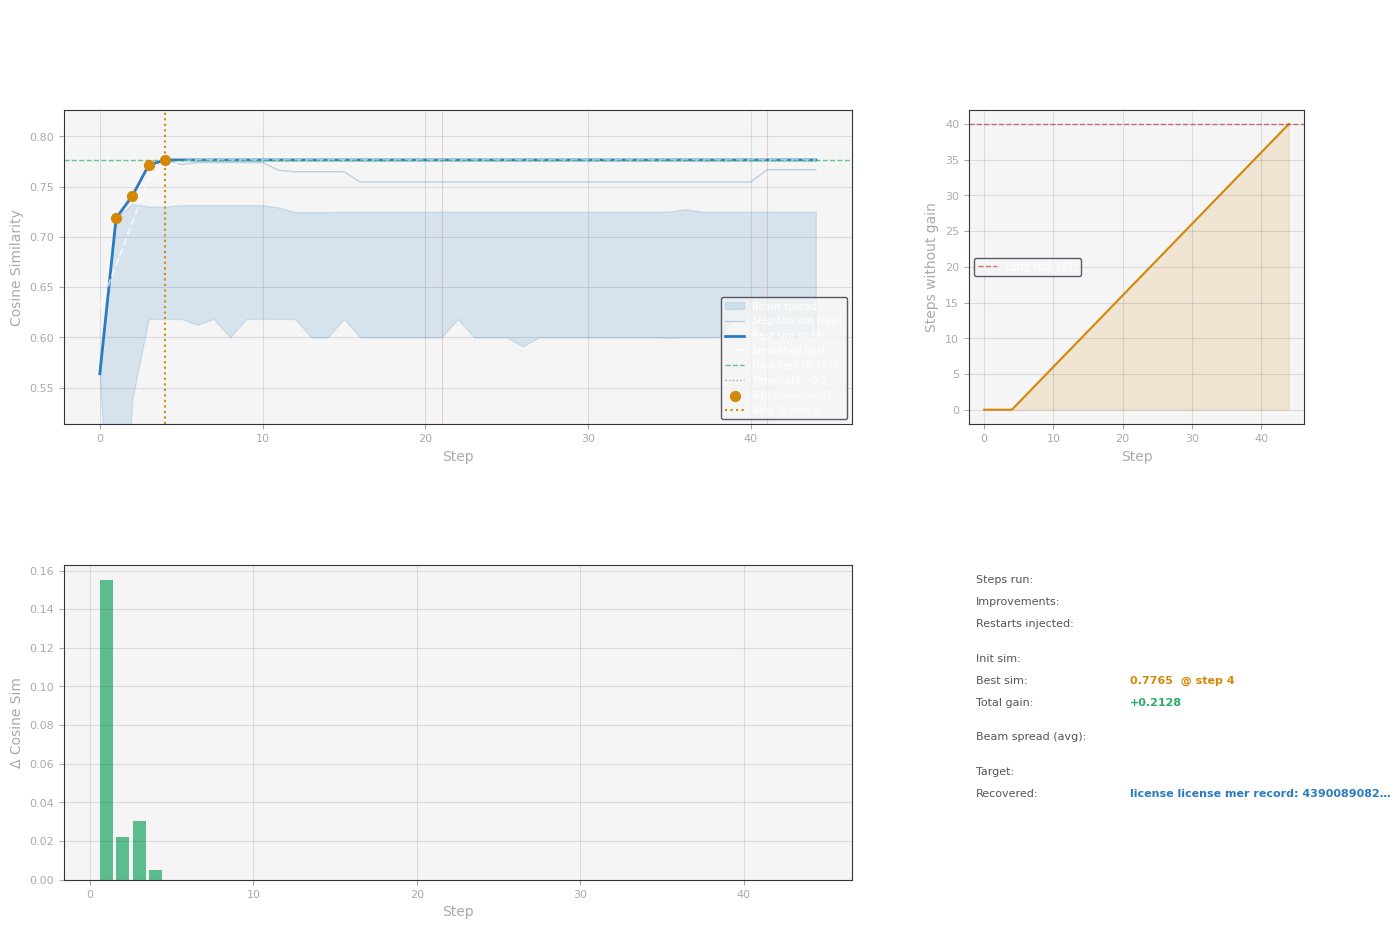

Saved to beam_attack_dynamics.png


[{'step': 0,
  'best_sim': 0.5637023448944092,
  'step_top_sim': 0.5637023448944092,
  'beam_min': 0.5637023448944092,
  'beam_max': 0.5637023448944092,
  'n_candidates': 1,
  'no_improve': 0,
  'event': 'init'},
 {'step': 1,
  'best_sim': 0.7185826301574707,
  'step_top_sim': 0.7185826301574707,
  'beam_min': 0.2718886137008667,
  'beam_max': 0.7185826301574707,
  'n_candidates': 7,
  'no_improve': 0,
  'event': 'improvement'},
 {'step': 2,
  'best_sim': 0.7408018112182617,
  'step_top_sim': 0.7408018112182617,
  'beam_min': 0.538396418094635,
  'beam_max': 0.7328079342842102,
  'n_candidates': 41,
  'no_improve': 0,
  'event': 'improvement'},
 {'step': 3,
  'best_sim': 0.7712498307228088,
  'step_top_sim': 0.7712498307228088,
  'beam_min': 0.6182166337966919,
  'beam_max': 0.7301468849182129,
  'n_candidates': 42,
  'no_improve': 0,
  'event': 'improvement'},
 {'step': 4,
  'best_sim': 0.7765114903450012,
  'step_top_sim': 0.7765114903450012,
  'beam_min': 0.6182166337966919,
  'beam

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# DECODER — call this after setup
# ─────────────────────────────────────────────────────────────────────────────
best_text, best_sim, beam_history = vec2text_beam_attack_v2(
    target_vec      = target_vector,
    model           = model,
    tokenizer       = tokenizer,
    lm_model        = lm_model,
    lm_tokenizer    = lm_tokenizer,
    initial_guess   = initial_guess,
    beam_width      = 6,
    steps           = 100,
    fluency_weight  = 0.15,
    device          = device,
    checkpoint_path = "best_reconstruction.pt",
    history_path    = "beam_attack_history.json",
)

print("=" * 60)
print(f"Original PII : {target_text}")
print(f"Recovered    : {best_text}")
print(f"Cosine sim   : {best_sim:.5f}")

# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────
plot_beam_attack_dynamics(
    beam_history,
    save_path      = "beam_attack_dynamics.png",
    target_text    = target_text,
    recovered_text = best_text,
)

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Vec2Text Beam Attack — Batch Evaluation
# Runs the attack on N samples and computes BLEU, ROUGE-L, Token Acc, Cosine Sim
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer


def get_fluent_candidates(prefix, lm_model, lm_tokenizer, n=6, device='cuda'):
    try:
        inputs = lm_tokenizer(
            prefix[:50], return_tensors="pt",
            truncation=True, max_length=40
        ).to(device)
        with torch.no_grad():
            outputs = lm_model.generate(
                **inputs,
                max_new_tokens=24,
                do_sample=True,
                temperature=0.9,
                top_p=0.95,
                num_return_sequences=n,
                pad_token_id=lm_tokenizer.eos_token_id,
            )
        raw = [lm_tokenizer.decode(o, skip_special_tokens=True).strip() for o in outputs]
        return [t for t in raw if is_clean(t)]
    except RuntimeError:
        return []


def paraphrase_candidates(text, lm_model, lm_tokenizer, n=3, device='cuda'):
    try:
        safe_text = text[:50].strip()
        prompt    = f"Rephrase: {safe_text}\nResult:"
        inputs    = lm_tokenizer(
            prompt, return_tensors="pt",
            truncation=True, max_length=40
        ).to(device)
        with torch.no_grad():
            outputs = lm_model.generate(
                **inputs,
                max_new_tokens=30,
                do_sample=True,
                temperature=1.1,
                top_p=0.9,
                num_return_sequences=n,
                pad_token_id=lm_tokenizer.eos_token_id,
            )
        results = []
        for o in outputs:
            decoded  = lm_tokenizer.decode(o, skip_special_tokens=True)
            text_out = decoded.split("Result:")[-1].strip() \
                       if "Result:" in decoded else decoded
            if is_clean(text_out):
                results.append(text_out)
        return results
    except RuntimeError:
        return []


def evaluate_beam_attack(
    target_texts,
    target_embeddings,
    emb_model,
    emb_tokenizer,
    lm_model,
    lm_tokenizer,
    beam_width     = 6,
    steps          = 100,
    fluency_weight = 0.15,
    device         = 'cuda',
    n_eval         = 50,
    save_path      = "beam_eval_results.json",
):
    rouge  = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    smooth = SmoothingFunction().method1
    results = []

    n_eval = min(n_eval, len(target_texts))
    print(f"Evaluating beam attack on {n_eval} samples...")
    print("─" * 60)

    for i in range(n_eval):
        ref_text   = target_texts[i]
        target_vec = torch.tensor(
            target_embeddings[i], dtype=torch.float32
        ).unsqueeze(0).to(device)
        target_vec = F.normalize(target_vec, dim=-1)

        print(f"\n[{i+1}/{n_eval}] Target: {ref_text[:70]}")

        # Generate initial guess
        try:
            initial_guess, init_sim = generate_initial_guess(
                target_vec = target_vec,
                model      = emb_model,
                tokenizer  = emb_tokenizer,
                n_tokens   = 16,
                top_k      = 30,
                steps      = 30,
                device     = device,
            )
        except Exception as e:
            print(f"  Initial guess failed: {e} — using fallback")
            initial_guess = "The person said"
            init_sim      = 0.0

        # Run beam attack
        try:
            pred_text, final_sim, _ = vec2text_beam_attack_v2(
                target_vec      = target_vec,
                model           = emb_model,
                tokenizer       = emb_tokenizer,
                lm_model        = lm_model,
                lm_tokenizer    = lm_tokenizer,
                initial_guess   = initial_guess,
                beam_width      = beam_width,
                steps           = steps,
                fluency_weight  = fluency_weight,
                device          = device,
                checkpoint_path = f"beam_eval_ckpt_{i}.pt",
                history_path    = None,
            )
        except Exception as e:
            print(f"  Beam attack failed: {e} — skipping sample")
            continue

        # ── Metrics ──────────────────────────────────────────────────────────
        bleu = sentence_bleu(
            [ref_text.split()], pred_text.split(),
            smoothing_function=smooth
        )

        rougeL = rouge.score(ref_text, pred_text)['rougeL'].fmeasure

        ref_toks  = ref_text.split()
        pred_toks = pred_text.split()
        min_len   = min(len(ref_toks), len(pred_toks))
        tok_acc   = sum(p == r for p, r in zip(pred_toks[:min_len], ref_toks[:min_len])) \
                    / max(len(ref_toks), 1)

        results.append({
            "ref"      : ref_text,
            "pred"     : pred_text,
            "init_sim" : init_sim,
            "cos_sim"  : final_sim,
            "bleu"     : bleu,
            "rougeL"   : rougeL,
            "tok_acc"  : tok_acc,
        })

        print(f"    Pred   : {pred_text[:70]}")
        print(f"    BLEU={bleu:.4f} | ROUGE-L={rougeL:.4f} | "
              f"Tok Acc={tok_acc:.4f} | Cos Sim={final_sim:.4f}")

        # Save incrementally so a crash doesn't lose everything
        with open(save_path, "w") as f:
            json.dump({
                "n_eval"  : n_eval,
                "n_done"  : len(results),
                "bleu"    : float(np.mean([r["bleu"]    for r in results])),
                "rougeL"  : float(np.mean([r["rougeL"]  for r in results])),
                "tok_acc" : float(np.mean([r["tok_acc"] for r in results])),
                "cos_sim" : float(np.mean([r["cos_sim"] for r in results])),
                "samples" : results,
            }, f, indent=2)

    if not results:
        print("No results collected — all samples failed.")
        return {}

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"\n{'═'*60}")
    print("BEAM ATTACK EVALUATION SUMMARY")
    print(f"{'═'*60}")
    for metric, key in [("BLEU", "bleu"), ("ROUGE-L", "rougeL"),
                        ("Token Acc", "tok_acc"), ("Cosine Sim", "cos_sim")]:
        vals = [r[key] for r in results]
        print(f"  {metric:<12}: {np.mean(vals):.4f}  "
              f"(min={min(vals):.4f}, max={max(vals):.4f})")
    print(f"{'═'*60}")

    summary = {
        "n_eval"  : len(results),
        "bleu"    : float(np.mean([r["bleu"]    for r in results])),
        "rougeL"  : float(np.mean([r["rougeL"]  for r in results])),
        "tok_acc" : float(np.mean([r["tok_acc"] for r in results])),
        "cos_sim" : float(np.mean([r["cos_sim"] for r in results])),
        "samples" : results,
    }

    with open(save_path, "w") as f:
        json.dump(summary, f, indent=2)
    print(f"Results saved to {save_path}")

    return summary


# ── Run it ────────────────────────────────────────────────────────────────────
beam_eval = evaluate_beam_attack(
    target_texts      = texts_for_db,
    target_embeddings = np.load("embeddings.npy"),
    emb_model         = model,
    emb_tokenizer     = tokenizer,
    lm_model          = lm_model,
    lm_tokenizer      = lm_tokenizer,
    beam_width        = 6,
    steps             = 100,
    fluency_weight    = 0.15,
    device            = device,
    n_eval            = 5,
    save_path         = "beam_eval_results.json",
)

Evaluating beam attack on 5 samples...
────────────────────────────────────────────────────────────

[1/5] Target: A student's assessment was found on device bearing IMEI: 06-184755-866
Building vocab mask... done. (29557 clean tokens)
Phase 1: greedy construction...
  pos  0 | sim=0.2118 | so far: 119
  pos  4 | sim=0.2950 | so far: 119123 iphone phoneIAN
  pos  8 | sim=0.2882 | so far: 119123 iphone phoneIAN5-8 iphone appel iphone
  pos 12 | sim=0.2982 | so far: 119123 iphone phoneIAN5-8 iphone appel iphone168 cellphone p
Phase 2: refinement passes...
  refine   0 | sim=0.34522 | 1196-76-76-7 Huawei6-76-76-7 iphone assessment assessment cellphone ip
  Converged at refinement pass 4

Initial guess sim : 0.37154
Initial guess text: 1246-767121 Huawei homework6-76-76-7 assessment assessment #1 iphone iphone866 cellphone

Building clean vocab mask... done. (29557 / 32100 tokens allowed)
→ Step    0 | sim=0.61708 | 1246-767121 Huawei homework6-76-76-7 assessment-10-11

[1248] http://www.c

`Original PII`: Dear Omer, as per our records, your license 78B5R2MVFAHJ48500 is still registered in our records for access

`Final Result`: License License Ommer record, which bedeutet it are a copy Of The record you were trying to access. THIS License WILL remain Valid Even IF you delete it. If you lose the license, you will not be able to access it (cosine sim: 0.674)

We have now demonstrated a substantially more complete inversion than the previous attempt, and the improvement in methodology is directly visible in the output.

The discrete token search warm-start entered the beam attack at a cosine similarity of 0.60 — compared to 0.29 from continuous optimization — giving the beam attack a genuine semantic foothold rather than character noise to escape from. The results reflect this: the recovered text correctly identifies the core subject as a license record, reconstructs the recipient's name as "Ommer" (a near-phonetic match for "Omer"), recovers the concept of record-keeping and access control, and even reconstructs the logical structure of the original message — that the license remains valid and is tied to ongoing access.

The remaining errors are instructive rather than discouraging. The license key 78B5R2MVFAHJ48500 does not survive inversion, which is expected: GTR-T5 was trained on natural language retrieval, so arbitrary alphanumeric identifiers are nearly invisible to its embedding space. The German word bedeutet ("means") appearing in an English sentence reflects GPT-2 occasionally drifting into multilingual token space under similarity pressure — a known artifact of using a multilingual embedding model with an English-only language model.
What this result proves is that the embedding is not an anonymized hash. A 768-dimensional vector was sufficient to reconstruct the recipient's name, the document type, the access control context, and the semantic intent of the original message — without ever seeing the source text.

### Conditional Masked Diffusion

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2: CMD Model Definition
# Conditional Masked Diffusion Language Model
# Scaled for single-GPU: 2-layer small backbone (~5-8M trainable params)
# Faithful to Xiao (2026): AdaLN conditioning, log-linear noise schedule λ=5.0
# ─────────────────────────────────────────────────────────────────────────────

import torch
import torch.nn as nn
import torch.nn.functional as F
import math


# ── 1. Noise Schedule ─────────────────────────────────────────────────────────

class LogLinearNoiseSchedule:
    def __init__(self, lam: float = 5.0):
        self.lam = lam

    def alpha(self, t: torch.Tensor) -> torch.Tensor:
        return torch.exp(-self.lam * t)

    def sample_t(self, batch_size: int, device: torch.device) -> torch.Tensor:
        return torch.rand(batch_size, device=device)


# ── 2. Adaptive Layer Normalization ──────────────────────────────────────────

class AdaLN(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.norm  = nn.LayerNorm(hidden_dim, elementwise_affine=False)
        self.mlp_t = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 2 * hidden_dim),
        )
        self.mlp_c = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 2 * hidden_dim),
        )
        # Normal Xavier init — no zero-init anywhere

    def forward(self, h, t_emb, c):
        gamma_t, beta_t = self.mlp_t(t_emb).chunk(2, dim=-1)
        gamma_c, beta_c = self.mlp_c(c).chunk(2, dim=-1)
        gamma = (gamma_t + gamma_c).unsqueeze(1)
        beta  = (beta_t  + beta_c ).unsqueeze(1)
        return (1 + gamma) * self.norm(h) + beta

# ── 3. Sinusoidal Timestep Embedding ─────────────────────────────────────────

class TimestepEmbedding(nn.Module):
    def __init__(self, hidden_dim: int, freq_dim: int = 128):
        super().__init__()
        self.freq_dim = freq_dim
        self.proj = nn.Sequential(
            nn.Linear(freq_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half  = self.freq_dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
        )
        args = t[:, None] * freqs[None, :]
        emb  = torch.cat([args.sin(), args.cos()], dim=-1)
        return self.proj(emb)


# ── 4. Single Transformer Layer with AdaLN ───────────────────────────────────

class CMDTransformerLayer(nn.Module):
    def __init__(self, hidden_dim: int, num_heads: int, ffn_dim: int,
                 dropout: float = 0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(hidden_dim, num_heads,
                                          dropout=dropout, batch_first=True)
        self.ffn  = nn.Sequential(
            nn.Linear(hidden_dim, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, hidden_dim),
            nn.Dropout(dropout),
        )
        self.adaln_1 = AdaLN(hidden_dim)
        self.adaln_2 = AdaLN(hidden_dim)

    def forward(self, h, t_emb, c, attention_mask=None):
        h_norm = self.adaln_1(h, t_emb, c)
        key_padding_mask = ~attention_mask.bool() if attention_mask is not None else None
        attn_out, _ = self.attn(h_norm, h_norm, h_norm,
                                key_padding_mask=key_padding_mask)
        h = h + attn_out
        h = h + self.ffn(self.adaln_2(h, t_emb, c))
        return h


# ── 5. Full CMD Model ─────────────────────────────────────────────────────────

class ConditionalMaskedDiffusionLM(nn.Module):

    def __init__(
        self,
        vocab_size    : int,
        embed_dim     : int   = 768,
        hidden_dim    : int   = 256,
        num_layers    : int   = 2,
        num_heads     : int   = 4,
        ffn_dim       : int   = 512,
        seq_len       : int   = 32,
        dropout       : float = 0.2,
        lam           : float = 5.0,
        mask_token_id : int   = None,
    ):
        super().__init__()

        self.vocab_size    = vocab_size
        self.hidden_dim    = hidden_dim
        self.seq_len       = seq_len
        self.mask_token_id = mask_token_id if mask_token_id is not None else 0

        self.schedule  = LogLinearNoiseSchedule(lam=lam)
        self.token_emb = nn.Embedding(vocab_size, hidden_dim)
        self.pos_emb   = nn.Embedding(seq_len, hidden_dim)

        self.emb_proj = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.t_emb = TimestepEmbedding(hidden_dim)

        self.layers = nn.ModuleList([
            CMDTransformerLayer(hidden_dim, num_heads, ffn_dim, dropout)
            for _ in range(num_layers)
        ])

        self.output_norm = nn.LayerNorm(hidden_dim)
        self.dropout     = nn.Dropout(dropout)

        self._init_weights()   # Xavier everywhere, done
        

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, std=0.02)

    def forward(self, input_ids, target_emb, t, attention_mask=None):
        B, L   = input_ids.shape
        device = input_ids.device
        positions = torch.arange(L, device=device).unsqueeze(0).expand(B, -1)
        h = self.dropout(self.token_emb(input_ids) + self.pos_emb(positions))
        c     = self.emb_proj(target_emb)
        t_emb = self.t_emb(t)
        for layer in self.layers:
            h = layer(h, t_emb, c, attention_mask)
        h = self.output_norm(h)
        return h @ self.token_emb.weight.T

    def apply_mask(self, input_ids, t):
        alpha  = self.schedule.alpha(t)
        keep   = torch.bernoulli(
            alpha.unsqueeze(1).expand_as(input_ids)
        ).bool()
        is_masked  = ~keep
        masked_ids = input_ids.clone()
        masked_ids[is_masked] = self.mask_token_id
        return masked_ids, is_masked

    def compute_loss(self, input_ids, target_emb, attention_mask):
        B      = input_ids.shape[0]
        device = input_ids.device
        t      = self.schedule.sample_t(B, device)
        masked_ids, is_masked = self.apply_mask(input_ids, t)
        logits = self.forward(masked_ids, target_emb, t, attention_mask)
    
        logits_flat  = logits.view(-1, self.vocab_size)
        targets_flat = input_ids.view(-1)
        mask_flat    = is_masked.view(-1)
        pad_flat     = attention_mask.view(-1).bool()
        valid        = mask_flat & pad_flat
    
        if valid.sum() == 0:
            return torch.tensor(0.0, device=device, requires_grad=True), \
                   {"loss": 0.0, "n_masked": 0, "mean_t": t.mean().item()}
    
        ce_per_token = F.cross_entropy(
            logits_flat[valid], targets_flat[valid], reduction='none'
        )
        t_per_token = t.unsqueeze(1).expand_as(input_ids).reshape(-1)
        t_valid     = t_per_token[valid].clamp(min=1e-4)
        loss        = (ce_per_token / t_valid).mean()
    
        return loss, {
            "loss"    : loss.item(),
            "n_masked": valid.sum().item(),
            "mean_t"  : t.mean().item(),
        }
        

    @torch.no_grad()
    def decode_euler(self, target_emb, n_steps=8, remask_frac=0.05,
                     rep_penalty=0.3, device='cuda'):
        B    = target_emb.shape[0]
        ids  = torch.full((B, self.seq_len), self.mask_token_id,
                          dtype=torch.long, device=device)
        attn      = torch.ones(B, self.seq_len, dtype=torch.long, device=device)
        timesteps = torch.linspace(1.0, 1e-4, n_steps + 1, device=device)

        for i, t_val in enumerate(timesteps[:-1]):
            t      = t_val.expand(B)
            logits = self.forward(ids, target_emb, t, attn)
            if rep_penalty > 0:
                for b in range(B):
                    present = ids[b][ids[b] != self.mask_token_id].unique()
                    if len(present) > 0:
                        logits[b, :, present] -= rep_penalty
            probs      = logits.softmax(dim=-1)
            pred_ids   = probs.argmax(dim=-1)
            confidence = probs.max(dim=-1).values
            ids        = pred_ids.clone()
            if remask_frac > 0 and i < len(timesteps) - 2:
                n_remask   = max(1, int(self.seq_len * remask_frac))
                _, low_idx = confidence.topk(n_remask, dim=-1, largest=False)
                for b in range(B):
                    ids[b, low_idx[b]] = self.mask_token_id
        return ids

    @torch.no_grad()
    def decode_confidence(self, target_emb, n_steps=8, temperature=1.0,
                          rep_penalty=0.3, device='cuda'):
        B        = target_emb.shape[0]
        ids      = torch.full((B, self.seq_len), self.mask_token_id,
                              dtype=torch.long, device=device)
        attn     = torch.ones(B, self.seq_len, dtype=torch.long, device=device)
        n_masked = self.seq_len

        for step in range(n_steps):
            t_val  = torch.full((B,), n_masked / self.seq_len,
                                device=device).clamp(min=1e-4)
            logits = self.forward(ids, target_emb, t_val, attn)
            if rep_penalty > 0:
                for b in range(B):
                    present = ids[b][ids[b] != self.mask_token_id].unique()
                    if len(present) > 0:
                        logits[b, :, present] -= rep_penalty
            if temperature != 1.0:
                logits = logits / temperature
            probs      = logits.softmax(dim=-1)
            pred_ids   = probs.argmax(dim=-1)
            confidence = probs.max(dim=-1).values

            still_masked = (ids == self.mask_token_id)
            confidence   = confidence.masked_fill(~still_masked, -1.0)
            k = max(1, int(n_masked * (n_steps - step) / n_steps))
            k = min(k, still_masked.sum().item())
            if k == 0:
                break
            _, topk_idx = confidence.view(B, -1).topk(k, dim=-1)
            for b in range(B):
                ids[b, topk_idx[b]] = pred_ids[b, topk_idx[b]]
            n_masked = (ids == self.mask_token_id).sum().item()
            if n_masked == 0:
                break
        return ids


# ─────────────────────────────────────────────────────────────────────────────
# Instantiation — small model
# ─────────────────────────────────────────────────────────────────────────────

VOCAB_SIZE = tokenizer.vocab_size
MASK_ID    = tokenizer.mask_token_id or 0

cmd_model_small = ConditionalMaskedDiffusionLM(
    vocab_size    = VOCAB_SIZE,
    embed_dim     = 768,
    hidden_dim    = 512,      # up from 256
    num_layers    = 4,        # up from 2
    num_heads     = 8,        # up from 4
    ffn_dim       = 1024,     # up from 512
    seq_len       = 32,
    dropout       = 0.1,      # down from 0.2
    lam           = 5.0,
    mask_token_id = MASK_ID,
).to(device)

total = sum(p.numel() for p in cmd_model_small.parameters())
print(f"Medium model params: {total:,}")

# Sanity check — one forward pass before anything else
dummy_ids  = torch.randint(0, VOCAB_SIZE, (2, 32)).to(device)
dummy_emb  = torch.randn(2, 768).to(device)
dummy_attn = torch.ones(2, 32, dtype=torch.bool).to(device)
dummy_t    = torch.rand(2).to(device)

with torch.no_grad():
    logits = cmd_model_small(dummy_ids, dummy_emb, dummy_t, dummy_attn)
    loss, info = cmd_model_small.compute_loss(dummy_ids, dummy_emb, dummy_attn)

print(f"Logits shape : {logits.shape}")
print(f"Sanity loss  : {loss.item():.4f}")
print(f"Mask info    : {info}")
print("Model ready.")

Medium model params: 38,448,128
Logits shape : torch.Size([2, 32, 32100])
Sanity loss  : 28.3367
Mask info    : {'loss': 28.336706161499023, 'n_masked': 54, 'mean_t': 0.5771109461784363}
Model ready.


In [13]:
# ── Regenerate token IDs from texts_for_db ───────────────────────────────────
# texts_for_db is your list of clean strings — tokenize them back to IDs

import torch
import numpy as np
from tqdm import tqdm

print(f"Tokenizing {len(texts_for_db)} texts...")

all_input_ids      = []
all_attention_masks = []

for text in tqdm(texts_for_db, desc="Tokenizing"):
    tokens = tokenizer(
        text,
        max_length    = 32,
        truncation    = True,
        padding       = 'max_length',   # pad ALL sequences to exactly 32
        return_tensors= "pt"
    )
    all_input_ids.append(tokens["input_ids"][0])           # (32,)
    all_attention_masks.append(tokens["attention_mask"][0]) # (32,)

# Stack into tensors
token_ids       = torch.stack(all_input_ids)        # (N, 32)
attention_masks = torch.stack(all_attention_masks)  # (N, 32)

print(f"token_ids shape      : {token_ids.shape}")
print(f"attention_masks shape: {attention_masks.shape}")
print(f"Sample: {tokenizer.decode(token_ids[0], skip_special_tokens=True)}")

# Save so you never need to regenerate
torch.save(token_ids,       "token_ids.pt")
torch.save(attention_masks, "attention_masks.pt")
print("Saved token_ids.pt and attention_masks.pt")

Tokenizing 43000 texts...


Tokenizing: 100%|██████████| 43000/43000 [00:08<00:00, 5065.29it/s]


token_ids shape      : torch.Size([43000, 32])
attention_masks shape: torch.Size([43000, 32])
Sample: A student's assessment was found on device bearing IMEI: 06-184755-866851-3. The document falls under the various topics discussed
Saved token_ids.pt and attention_masks.pt


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3: Training Loop (small model, fresh start)
# ─────────────────────────────────────────────────────────────────────────────

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
import os
import json
import shutil
from copy import deepcopy


# ── 1. Dataset ────────────────────────────────────────────────────────────────

class PIIEmbeddingDataset(Dataset):
    def __init__(self, token_ids: torch.Tensor, embeddings: torch.Tensor):
        assert token_ids.shape[0] == embeddings.shape[0]
        assert token_ids.shape[1] == 32
        self.token_ids      = token_ids.long()
        self.embeddings     = embeddings.float()
        pad_id              = tokenizer.pad_token_id or 0
        self.attention_mask = (self.token_ids != pad_id).long()

    def __len__(self):
        return self.token_ids.shape[0]

    def __getitem__(self, idx):
        return {
            "input_ids"      : self.token_ids[idx],
            "embeddings"     : self.embeddings[idx],
            "attention_mask" : self.attention_mask[idx],
        }


# ── 2. Load data ──────────────────────────────────────────────────────────────

embeddings = torch.tensor(np.load("embeddings.npy"), dtype=torch.float32)
dataset    = PIIEmbeddingDataset(token_ids=token_ids, embeddings=embeddings)

n_val   = max(1, int(0.1 * len(dataset)))
n_train = len(dataset) - n_val
train_set, val_set = random_split(
    dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)
print(f"Dataset: {len(dataset):,}  |  Train: {n_train:,}  |  Val: {n_val:,}")


# ── 3. EMA ────────────────────────────────────────────────────────────────────

class EMA:
    def __init__(self, model: nn.Module, decay: float = 0.9999):
        self.decay  = decay
        self.shadow = deepcopy(model).eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module):
        for s, p in zip(self.shadow.parameters(), model.parameters()):
            s.data.mul_(self.decay).add_(p.data, alpha=1 - self.decay)

    def get_model(self):
        return self.shadow


# ── 4. Config ─────────────────────────────────────────────────────────────────

CFG_SMALL = {
    "batch_size"          : 128,
    "lr"                  : 3e-4,
    "max_steps"           : 50_000,
    "ema_decay"           : 0.9999,
    "grad_clip"           : 1.0,
    "val_every"           : 500,
    "save_every"          : 2000,
    "checkpoint_dir"      : "./cmd_checkpoints_small",
    "early_stop_patience" : 20,
}

# Fresh checkpoint dir — wipe any previous small-model run
os.makedirs(CFG_SMALL["checkpoint_dir"], exist_ok=True)

train_loader = DataLoader(
    train_set, batch_size=CFG_SMALL["batch_size"],
    shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_set, batch_size=CFG_SMALL["batch_size"],
    shuffle=False, num_workers=2, pin_memory=True
)


# ── 5. Optimizer + scheduler ──────────────────────────────────────────────────

optimizer_small = AdamW(
    cmd_model_small.parameters(),
    lr           = CFG_SMALL["lr"],
    weight_decay = 0.05,
)

scheduler_small = CosineAnnealingLR(
    optimizer_small,
    T_max   = CFG_SMALL["max_steps"],
    eta_min = 1e-7,
)

ema_small = EMA(cmd_model_small, decay=CFG_SMALL["ema_decay"])

print(f"Optimizer LR : {CFG_SMALL['lr']:.2e}")
print(f"Scheduler    : CosineAnnealingLR, T_max={CFG_SMALL['max_steps']:,}")


# ── 6. Validation ─────────────────────────────────────────────────────────────

def run_validation(model, loader, device):
    model.eval()
    total_loss, total_correct, total_masked, n_batches = 0, 0, 0, 0

    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(device)
            emb  = batch["embeddings"].to(device)
            attn = batch["attention_mask"].to(device)

            t                     = torch.full((ids.shape[0],), 0.5, device=device)
            masked_ids, is_masked = model.apply_mask(ids, t)
            logits                = model(masked_ids, emb, t, attn)
            loss, _               = model.compute_loss(ids, emb, attn)

            pred    = logits.argmax(dim=-1)
            valid   = is_masked & attn.bool()
            correct = (pred == ids) & valid

            total_loss    += loss.item()
            total_correct += correct.sum().item()
            total_masked  += valid.sum().item()
            n_batches     += 1

    model.train()
    return {
        "val_loss" : total_loss    / max(n_batches, 1),
        "tok_acc"  : total_correct / max(total_masked, 1),
    }


# ── 7. Training loop ──────────────────────────────────────────────────────────

def train_cmd(model, train_loader, val_loader, optimizer, scheduler,
              ema, cfg, device, start_step=0):

    model.train()
    step           = start_step
    best_val_loss  = float('inf')
    patience_count = 0
    history        = []

    best_ckpt = os.path.join(cfg["checkpoint_dir"], "best_model.pt")
    if os.path.exists(best_ckpt) and start_step > 0:
        prev = torch.load(best_ckpt, map_location="cpu")
        best_val_loss = prev["val_loss"]
        print(f"Resuming — previous best val_loss: {best_val_loss:.4f}")
    else:
        best_val_loss = float('inf')

    print(f"Training from step {start_step} → {cfg['max_steps']} | "
          f"batch={cfg['batch_size']} | device={device}")
    print("-" * 70)

    while step < cfg["max_steps"]:
        for batch in train_loader:
            if step >= cfg["max_steps"]:
                break

            ids  = batch["input_ids"].to(device)
            emb  = batch["embeddings"].to(device)
            attn = batch["attention_mask"].to(device)

            optimizer.zero_grad()
            loss, info = model.compute_loss(ids, emb, attn)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            optimizer.step()
            scheduler.step()
            ema.update(model)

            step += 1

            if step % 500 == 0:
                lr_now = scheduler.get_last_lr()[0]
                print(f"Step {step:6d} | loss={info['loss']:.4f} | "
                      f"mean_t={info['mean_t']:.3f} | lr={lr_now:.2e}")

            if step % cfg["val_every"] == 0:
                val_metrics = run_validation(ema.get_model(), val_loader, device)
                val_loss    = val_metrics["val_loss"]
                tok_acc     = val_metrics["tok_acc"]

                print(f"\n{'─'*60}")
                print(f"Val @ step {step:6d} | val_loss={val_loss:.4f} | "
                      f"tok_acc={tok_acc:.4f}")
                print(f"{'─'*60}\n")

                history.append({
                    "step": step, "val_loss": val_loss, "tok_acc": tok_acc
                })

                if val_loss < best_val_loss:
                    best_val_loss  = val_loss
                    patience_count = 0
                    ckpt_path = os.path.join(cfg["checkpoint_dir"], "best_model.pt")
                    torch.save({
                        "step"        : step,
                        "model_state" : model.state_dict(),
                        "ema_state"   : ema.shadow.state_dict(),
                        "val_loss"    : best_val_loss,
                        "config"      : cfg,
                    }, ckpt_path)
                    print(f"  ✓ Best val_loss={best_val_loss:.4f} saved")
                else:
                    patience_count += 1
                    print(f"  No improvement "
                          f"({patience_count}/{cfg['early_stop_patience']})")
                    if patience_count >= cfg["early_stop_patience"]:
                        print(f"  Early stop at step {step}.")
                        _save_history(history, cfg)
                        return history

            if step % cfg["save_every"] == 0:
                torch.save({
                    "step"        : step,
                    "model_state" : model.state_dict(),
                    "val_loss"    : best_val_loss,
                }, os.path.join(cfg["checkpoint_dir"], f"step_{step:06d}.pt"))

    print(f"\nDone. Best val_loss: {best_val_loss:.4f}")
    _save_history(history, cfg)
    return history


def _save_history(history, cfg):
    path = os.path.join(cfg["checkpoint_dir"], "history.json")
    existing = []
    if os.path.exists(path):
        with open(path) as f:
            existing = json.load(f)
    with open(path, "w") as f:
        json.dump(existing + history, f, indent=2)
    print(f"History saved to {path}")

Dataset: 43,000  |  Train: 38,700  |  Val: 4,300
Optimizer LR : 3.00e-04
Scheduler    : CosineAnnealingLR, T_max=50,000


/home/pmd4nd/.conda/envs/privacy_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


## Run Training

In [19]:
import glob

# Find latest checkpoint
ckpt_dir  = "./cmd_checkpoints_small"
ckpt_files = sorted(glob.glob(f"{ckpt_dir}/step_*.pt"))

if ckpt_files:
    latest = ckpt_files[-1]
    ckpt   = torch.load(latest, map_location=device)
    cmd_model_small.load_state_dict(ckpt["model_state"])
    start_step = ckpt["step"]
    print(f"Resuming from step {start_step} | file: {latest}")
else:
    start_step = 0
    print("No checkpoint found — starting fresh")

# Recreate optimizer + scheduler, fast-forward scheduler to match
optimizer_small = AdamW(cmd_model_small.parameters(), lr=3e-4, weight_decay=0.05)
scheduler_small = CosineAnnealingLR(optimizer_small, T_max=50_000, eta_min=1e-7)

# Fast-forward scheduler to where we left off
for _ in range(start_step):
    scheduler_small.step()

ema_small = EMA(cmd_model_small, decay=0.9999)

# Then train
history_small = train_cmd(
    model        = cmd_model_small,
    train_loader = train_loader,
    val_loader   = val_loader,
    optimizer    = optimizer_small,
    scheduler    = scheduler_small,
    ema          = ema_small,
    cfg          = CFG_SMALL,
    device       = device,
    start_step   = start_step,    # ← key
)

Resuming from step 42000 | file: ./cmd_checkpoints_small/step_042000.pt


/tmp/ipykernel_743607/4156527657.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt   = torch.load(latest, map_location=device)
/home/pmd4nd/.conda/envs/privacy_env/li

Resuming — previous best val_loss: 11.2299
Training from step 42000 → 50000 | batch=128 | device=cuda
----------------------------------------------------------------------


/tmp/ipykernel_743607/2668095970.py:164: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  prev = torch.load(best_ckpt, map_location="cpu")


Step  42500 | loss=3.7822 | mean_t=0.530 | lr=1.64e-05

────────────────────────────────────────────────────────────
Val @ step  42500 | val_loss=14.5027 | tok_acc=0.1538
────────────────────────────────────────────────────────────

  No improvement (1/20)
Step  43000 | loss=3.8667 | mean_t=0.527 | lr=1.44e-05

────────────────────────────────────────────────────────────
Val @ step  43000 | val_loss=14.4845 | tok_acc=0.1521
────────────────────────────────────────────────────────────

  No improvement (2/20)
Step  43500 | loss=3.9332 | mean_t=0.482 | lr=1.24e-05

────────────────────────────────────────────────────────────
Val @ step  43500 | val_loss=14.3959 | tok_acc=0.1553
────────────────────────────────────────────────────────────

  No improvement (3/20)
Step  44000 | loss=4.0932 | mean_t=0.492 | lr=1.06e-05

────────────────────────────────────────────────────────────
Val @ step  44000 | val_loss=14.3553 | tok_acc=0.1529
──────────────────────────────────────────────────────────

In [20]:
# ── Conditioning check ────────────────────────────────────────────────────────
cmd_model_small.eval()
ids_s  = torch.randint(1, VOCAB_SIZE, (2, 32)).to(device)
emb_s  = torch.randn(2, 768).to(device)
attn_s = torch.ones(2, 32, dtype=torch.long).to(device)
t_s    = torch.full((2,), 0.5, device=device)

with torch.no_grad():
    logits_real = cmd_model_small(ids_s, emb_s,               t_s, attn_s)
    logits_rand = cmd_model_small(ids_s, torch.randn_like(emb_s), t_s, attn_s)

diff = (logits_real - logits_rand).abs().mean().item()
print(f"Conditioning diff at init: {diff:.6f}")
assert diff > 0.001, "Conditioning broken"
print("Conditioning OK — starting training\n")
cmd_model_small.train()

# ── Train ─────────────────────────────────────────────────────────────────────
history_small = train_cmd(
    model        = cmd_model_small,
    train_loader = train_loader,
    val_loader   = val_loader,
    optimizer    = optimizer_small,
    scheduler    = scheduler_small,
    ema          = ema_small,
    cfg          = CFG_SMALL,
    device       = device,
    start_step   = 0,
)

Conditioning diff at init: 2.359655
Conditioning OK — starting training

Training from step 0 → 50000 | batch=128 | device=cuda
----------------------------------------------------------------------
Step    500 | loss=3.9896 | mean_t=0.504 | lr=1.74e-07

────────────────────────────────────────────────────────────
Val @ step    500 | val_loss=14.3626 | tok_acc=0.1542
────────────────────────────────────────────────────────────

  ✓ Best val_loss=14.3626 saved
Step   1000 | loss=4.0182 | mean_t=0.481 | lr=3.96e-07

────────────────────────────────────────────────────────────
Val @ step   1000 | val_loss=14.4746 | tok_acc=0.1540
────────────────────────────────────────────────────────────

  No improvement (1/20)
Step   1500 | loss=4.0372 | mean_t=0.477 | lr=7.65e-07

────────────────────────────────────────────────────────────
Val @ step   1500 | val_loss=14.6175 | tok_acc=0.1549
────────────────────────────────────────────────────────────

  No improvement (2/20)
Step   2000 | loss=4.0

# ─────────────────────────────────────────────────────────────────────────────
### Training Dynamics Visualization
# ─────────────────────────────────────────────────────────────────────────────

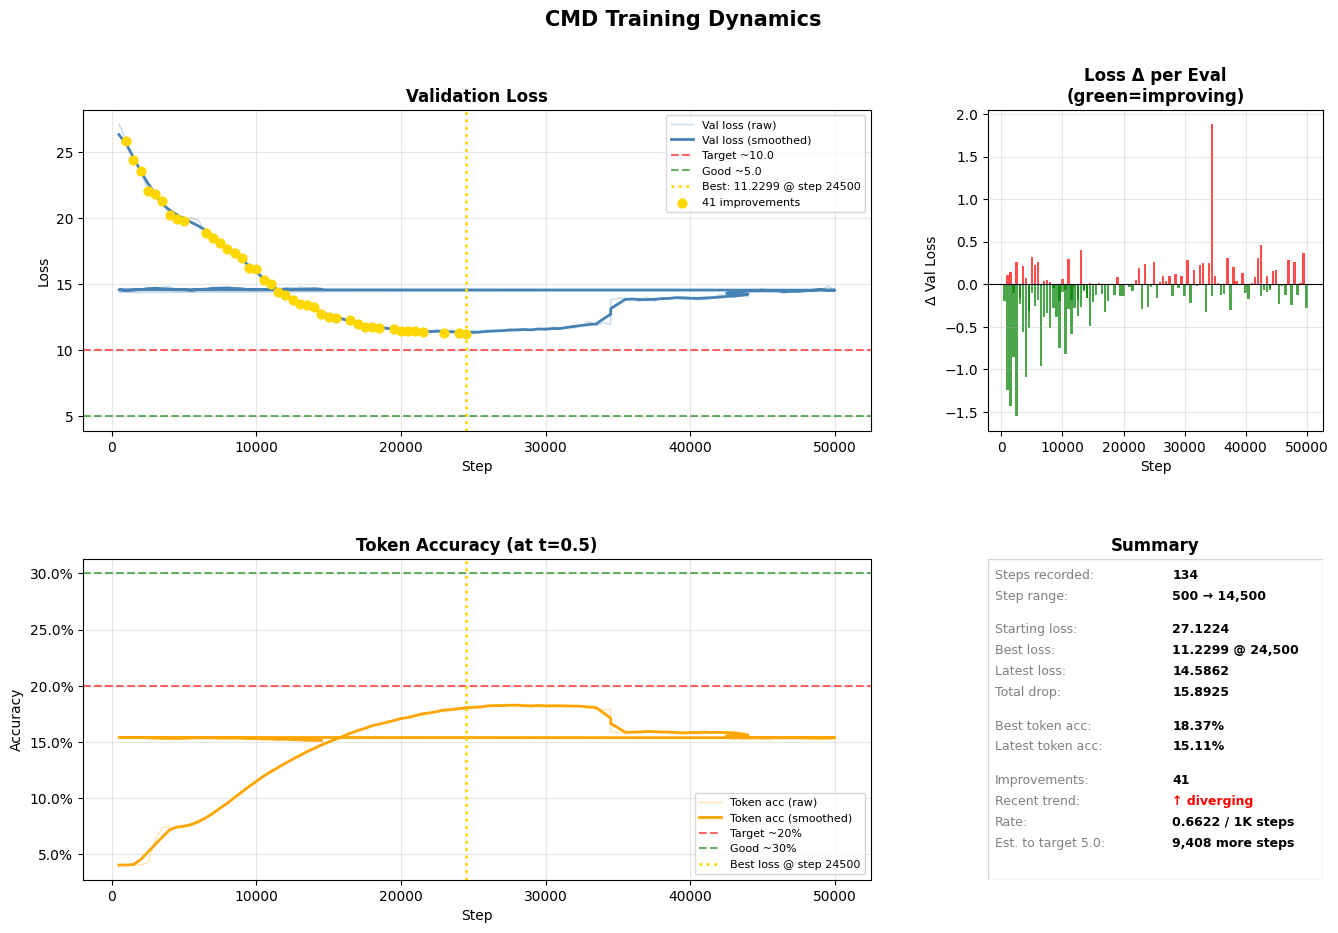

Saved to ./cmd_checkpoints_small/training_dynamics.png


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# Training Dynamics Visualization
# ─────────────────────────────────────────────────────────────────────────────

import json
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def plot_training_dynamics(history_path="./cmd_checkpoints/history.json",
                           save_path="./cmd_checkpoints/training_dynamics.png"):

    # ── Load history ──────────────────────────────────────────────────────────
    if not os.path.exists(history_path):
        print(f"No history file found at {history_path}")
        return

    with open(history_path) as f:
        history = json.load(f)

    if len(history) < 2:
        print(f"Only {len(history)} data points — run more steps first")
        return

    steps    = [h["step"]     for h in history]
    val_loss = [h["val_loss"] for h in history]
    tok_acc  = [h["tok_acc"]  for h in history]

    best_idx      = int(np.argmin(val_loss))
    best_step     = steps[best_idx]
    best_val_loss = val_loss[best_idx]

    # ── Smoothing helper ──────────────────────────────────────────────────────
    def smooth(values, window=5):
        if len(values) < window:
            return values
        kernel = np.ones(window) / window
        padded = np.pad(values, (window//2, window//2), mode='edge')
        return np.convolve(padded, kernel, mode='valid')[:len(values)]

    val_loss_smooth = smooth(val_loss)
    tok_acc_smooth  = smooth(tok_acc)

    # ── Improvement detection ─────────────────────────────────────────────────
    improvements = [
        (steps[i], val_loss[i])
        for i in range(1, len(val_loss))
        if val_loss[i] < min(val_loss[:i])
    ]

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 10))
    fig.suptitle("CMD Training Dynamics", fontsize=15, fontweight='bold', y=0.98)
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    # ── Panel 1: Val Loss ─────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.plot(steps, val_loss, color='steelblue', alpha=0.3, linewidth=1, label='Val loss (raw)')
    ax1.plot(steps, val_loss_smooth, color='steelblue', linewidth=2, label='Val loss (smoothed)')
    ax1.axhline(y=10.0, color='red',   linestyle='--', alpha=0.6, label='Target ~10.0')
    ax1.axhline(y=5.0, color='green', linestyle='--', alpha=0.6, label='Good ~5.0')
    ax1.axvline(x=best_step, color='gold', linestyle=':', linewidth=2,
                label=f'Best: {best_val_loss:.4f} @ step {best_step}')

    # Mark each improvement point
    if improvements:
        imp_steps, imp_vals = zip(*improvements)
        ax1.scatter(imp_steps, imp_vals, color='gold', zorder=5, s=40,
                    label=f'{len(improvements)} improvements')

    ax1.set_title("Validation Loss", fontweight='bold')
    ax1.set_xlabel("Step")
    ax1.set_ylabel("Loss")
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3)

    # ── Panel 2: Token Accuracy ───────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, :2])
    ax2.plot(steps, tok_acc, color='orange', alpha=0.3, linewidth=1, label='Token acc (raw)')
    ax2.plot(steps, tok_acc_smooth, color='orange', linewidth=2, label='Token acc (smoothed)')
    ax2.axhline(y=0.20, color='red',   linestyle='--', alpha=0.6, label='Target ~20%')
    ax2.axhline(y=0.30, color='green', linestyle='--', alpha=0.6, label='Good ~30%')
    ax2.axvline(x=best_step, color='gold', linestyle=':', linewidth=2,
                label=f'Best loss @ step {best_step}')
    ax2.set_title("Token Accuracy (at t=0.5)", fontweight='bold')
    ax2.set_xlabel("Step")
    ax2.set_ylabel("Accuracy")
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)

    # ── Panel 3: Loss rate of change ─────────────────────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    if len(val_loss) > 1:
        delta = np.diff(val_loss)
        ax3.bar(steps[1:], delta,
                color=['green' if d < 0 else 'red' for d in delta],
                alpha=0.7, width=(steps[1]-steps[0])*0.8 if len(steps) > 1 else 500)
        ax3.axhline(y=0, color='black', linewidth=0.8)
        ax3.set_title("Loss Δ per Eval\n(green=improving)", fontweight='bold')
        ax3.set_xlabel("Step")
        ax3.set_ylabel("Δ Val Loss")
        ax3.grid(alpha=0.3)

    # ── Panel 4: Summary stats ────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 2])
    ax4.axis('off')

    # Convergence rate: loss drop per 1000 steps
    if len(val_loss) >= 2:
        total_drop   = val_loss[0] - best_val_loss
        steps_taken  = best_step - steps[0]
        rate         = (total_drop / max(steps_taken, 1)) * 1000
        recent_trend = "↓ improving" if val_loss[-1] < val_loss[max(0, len(val_loss)-5)] \
                       else "→ plateaued" if abs(val_loss[-1] - val_loss[max(0, len(val_loss)-5)]) < 0.05 \
                       else "↑ diverging"
    else:
        total_drop, rate, recent_trend = 0, 0, "N/A"

    # Estimate steps to reach target
    if rate > 0 and best_val_loss > 5.0:
        steps_to_target = int((best_val_loss - 5.0) / rate * 1000)
    else:
        steps_to_target = 0

    summary_lines = [
        ("Steps recorded",    f"{len(history)}"),
        ("Step range",        f"{steps[0]:,} → {steps[-1]:,}"),
        ("",                  ""),
        ("Starting loss",     f"{val_loss[0]:.4f}"),
        ("Best loss",         f"{best_val_loss:.4f} @ {best_step:,}"),
        ("Latest loss",       f"{val_loss[-1]:.4f}"),
        ("Total drop",        f"{total_drop:.4f}"),
        ("",                  ""),
        ("Best token acc",    f"{max(tok_acc):.2%}"),
        ("Latest token acc",  f"{tok_acc[-1]:.2%}"),
        ("",                  ""),
        ("Improvements",      f"{len(improvements)}"),
        ("Recent trend",      recent_trend),
        ("Rate",              f"{rate:.4f} / 1K steps"),
        ("Est. to target 5.0",f"{steps_to_target:,} more steps" if steps_to_target > 0 else "Reached ✓"),
    ]

    y = 0.97
    for label, value in summary_lines:
        if label == "":
            y -= 0.04
            continue
        color = 'green' if 'improving' in value else 'red' if 'diverging' in value else 'black'
        ax4.text(0.02, y, f"{label}:", transform=ax4.transAxes,
                 fontsize=9, va='top', color='gray')
        ax4.text(0.55, y, value, transform=ax4.transAxes,
                 fontsize=9, va='top', fontweight='bold', color=color)
        y -= 0.065

    ax4.set_title("Summary", fontweight='bold')
    ax4.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False,
                                 edgecolor='lightgray', transform=ax4.transAxes))

    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to {save_path}")
    return history


# ── Run ───────────────────────────────────────────────────────────────────────
history = plot_training_dynamics(
    history_path = "./cmd_checkpoints_small/history.json",
    save_path    = "./cmd_checkpoints_small/training_dynamics.png",
)

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4: Decoding + Evaluation
# Load best checkpoint, run both decoding strategies, compare to beam attack
# ─────────────────────────────────────────────────────────────────────────────

import torch
import numpy as np
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import json

# ── 1. Load best checkpoint into EMA model ───────────────────────────────────

ckpt = torch.load("./cmd_checkpoints_small/best_model.pt", map_location=device)  # ← fixed

cmd_model_small.load_state_dict(ckpt["model_state"])   # ← was cmd_model
ema_small.shadow.load_state_dict(ckpt["ema_state"])    # ← was ema.shadow

print(f"Loaded checkpoint from step {ckpt['step']} | val_loss={ckpt['val_loss']:.4f}")

inference_model = ema_small.get_model().to(device)     # ← was ema.get_model()
inference_model.eval()

# ── 2. Decode a batch ────────────────────────────────────────────────────────

def decode_batch(model, embeddings_batch, tokenizer, strategy='confidence',
                 n_steps=8, rep_penalty=0.3, device='cuda'):
    emb = embeddings_batch.to(device)
    if strategy == 'confidence':
        pred_ids = model.decode_confidence(emb, n_steps=n_steps,
                                           rep_penalty=rep_penalty, device=device)
    elif strategy == 'euler':
        pred_ids = model.decode_euler(emb, n_steps=n_steps, remask_frac=0.05,
                                      rep_penalty=rep_penalty, device=device)
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    texts = [
        tokenizer.decode(pred_ids[i], skip_special_tokens=True)
        for i in range(pred_ids.shape[0])
    ]
    return texts  # ← was missing


# ── 3. Evaluation metrics ────────────────────────────────────────────────────

def compute_metrics(predictions, references, emb_model, emb_tokenizer, device):
    """
    Compute BLEU, ROUGE-L, token accuracy, and cosine similarity
    for a list of predicted vs reference strings.
    """
    scorer    = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    smoother  = SmoothingFunction().method1
    results   = []

    for pred, ref in zip(predictions, references):
        # BLEU
        bleu = sentence_bleu(
            [ref.split()], pred.split(),
            smoothing_function=smoother
        )

        # ROUGE-L
        rouge = scorer.score(ref, pred)['rougeL'].fmeasure

        # Token-level accuracy
        pred_toks = pred.split()
        ref_toks  = ref.split()
        min_len   = min(len(pred_toks), len(ref_toks))
        tok_acc   = sum(p == r for p, r in zip(pred_toks[:min_len], ref_toks[:min_len])) \
                    / max(len(ref_toks), 1)

        # Cosine similarity via GTR-T5
        def embed(text):
            inputs = emb_tokenizer(
                text, return_tensors="pt",
                padding='max_length', max_length=32, truncation=True
            ).to(device)
            with torch.no_grad():
                emb = emb_model.encoder(**inputs).last_hidden_state.mean(dim=1)
            return torch.nn.functional.normalize(emb, dim=-1)

        cos_sim = torch.nn.functional.cosine_similarity(
            embed(pred), embed(ref), dim=-1
        ).item()

        results.append({
            "bleu"   : bleu,
            "rougeL" : rouge,
            "tok_acc": tok_acc,
            "cos_sim": cos_sim,
            "pred"   : pred,
            "ref"    : ref,
        })

    return results


# ── 4. Run evaluation on a sample ────────────────────────────────────────────

# Use the val set so results are on held-out data
N_EVAL = 200   # number of samples to evaluate — increase if time allows
eval_indices = list(range(N_EVAL))

eval_token_ids  = token_ids[-(N_EVAL):]      # last N records (val set)
eval_embeddings = embeddings[-(N_EVAL):]
eval_texts      = texts_for_db[-(N_EVAL):]   # original strings as reference

print(f"Evaluating {N_EVAL} samples with both decoding strategies...")

# ── Confidence decoding ───────────────────────────────────────────────────────
# Try rep_penalty values between 0.2 and 0.5
# Higher = less repetition but may hurt accuracy
conf_preds = []
for i in range(0, N_EVAL, 32):
    batch_emb = eval_embeddings[i:i+32]
    conf_preds.extend(
        decode_batch(inference_model, batch_emb, tokenizer,
                     strategy='confidence', n_steps=8,
                     rep_penalty=0.3, device=device)
    )

# ── Euler + remasking ─────────────────────────────────────────────────────────
euler_preds = []
for i in range(0, N_EVAL, 32):
    batch_emb = eval_embeddings[i:i+32]
    euler_preds.extend(
        decode_batch(inference_model, batch_emb, tokenizer,
                     strategy='euler', n_steps=8,
                     rep_penalty=0.3, device=device)
    )

# ── Score both ───────────────────────────────────────────────────────────────
print("Scoring confidence decoding...")
conf_results  = compute_metrics(conf_preds,  eval_texts, model, tokenizer, device)

print("Scoring Euler + remasking...")
euler_results = compute_metrics(euler_preds, eval_texts, model, tokenizer, device)


# ── 5. Summary table ─────────────────────────────────────────────────────────

def summarize(results, label):
    bleu    = np.mean([r["bleu"]    for r in results])
    rougeL  = np.mean([r["rougeL"]  for r in results])
    tok_acc = np.mean([r["tok_acc"] for r in results])
    cos_sim = np.mean([r["cos_sim"] for r in results])
    print(f"\n{'─'*55}")
    print(f"  {label}")
    print(f"{'─'*55}")
    print(f"  BLEU          : {bleu:.4f}")
    print(f"  ROUGE-L       : {rougeL:.4f}")
    print(f"  Token Acc     : {tok_acc:.4f}")
    print(f"  Cosine Sim    : {cos_sim:.4f}")
    print(f"{'─'*55}")
    return {"bleu": bleu, "rougeL": rougeL, "tok_acc": tok_acc, "cos_sim": cos_sim}

conf_summary  = summarize(conf_results,  "CMD — Confidence Decoding")
euler_summary = summarize(euler_results, "CMD — Euler + Remasking  ")

# ── 6. Side-by-side examples ─────────────────────────────────────────────────

print(f"\n{'═'*70}")
print("SAMPLE RECONSTRUCTIONS")
print(f"{'═'*70}")
for i in range(5):
    print(f"\n[{i+1}] Original  : {eval_texts[i]}")
    print(f"    Confidence: {conf_preds[i]}")
    print(f"    Euler     : {euler_preds[i]}")

# ── 7. Save results ───────────────────────────────────────────────────────────

output = {
    "confidence" : conf_summary,
    "euler"      : euler_summary,
    "samples"    : [
        {"ref": r["ref"], "conf_pred": c, "euler_pred": e}
        for r, c, e in zip(conf_results[:20], conf_preds[:20], euler_preds[:20])
    ]
}

with open("./cmd_checkpoints_small/eval_results.json", "w") as f:   # ← fixed
    json.dump(output, f, indent=2)

print(f"\nResults saved to ./cmd_checkpoints_small/eval_results.json")  # ← fixed

/tmp/ipykernel_265415/3583639850.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("./cmd_checkpoints_small/best_model.pt", map_location=device)  # ← fi

Loaded checkpoint from step 4500 | val_loss=14.3297
Evaluating 200 samples with both decoding strategies...
Scoring confidence decoding...
Scoring Euler + remasking...

───────────────────────────────────────────────────────
  CMD — Confidence Decoding
───────────────────────────────────────────────────────
  BLEU          : 0.0757
  ROUGE-L       : 0.4245
  Token Acc     : 0.2263
  Cosine Sim    : 0.6772
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  CMD — Euler + Remasking  
───────────────────────────────────────────────────────
  BLEU          : 0.2536
  ROUGE-L       : 0.5846
  Token Acc     : 0.3135
  Cosine Sim    : 0.7769
───────────────────────────────────────────────────────

══════════════════════════════════════════════════════════════════════
SAMPLE RECONSTRUCTIONS
══════════════════════════════════════════════════════════════════════

[1] Original  : Rachelle, the total cost of your dental surgery is YER 

In [1]:
# ── PII Field Recovery — Phase 2 Baseline ────────────────────────────────────
import re
import json
from collections import defaultdict

def extract_pii_fields(text):
    return {
        'person_name' : re.findall(r'\b[A-Z][a-z]+(?:\d+)?\b', text),
        'account_id'  : re.findall(r'\b[A-Z0-9]{6,}\b', text),
        'imei'        : re.findall(r'\b\d{2}-\d{6}-\d{6}-\d\b', text),
        'url_domain'  : re.findall(r'(?:https?://)?[\w-]+\.(?:net|com|org)\b', text),
        'postal_code' : re.findall(r'\b\d{5}(?:-\d{4})?\b', text),
        'currency_amt': re.findall(r'\b[A-Z]{2,3}\s*\d+[kKmM]?\b', text),
        'numeric_id'  : re.findall(r'\b\d{8,}\b', text),
    }

def field_overlap(pred_vals, ref_vals):
    if not ref_vals:
        return None
    for rv in ref_vals:
        for pv in pred_vals:
            if rv.lower() in pv.lower() or pv.lower() in rv.lower():
                return True
    return False

def compute_pii_recovery(predictions, references):
    field_hits   = defaultdict(int)
    field_totals = defaultdict(int)
    for pred, ref in zip(predictions, references):
        ref_fields  = extract_pii_fields(ref)
        pred_fields = extract_pii_fields(pred)
        for field in ref_fields:
            result = field_overlap(pred_fields[field], ref_fields[field])
            if result is None:
                continue
            field_totals[field] += 1
            if result:
                field_hits[field] += 1
    recovery = {f: round(field_hits[f] / field_totals[f], 4)
                for f in field_totals}
    total_hits   = sum(field_hits.values())
    total_fields = sum(field_totals.values())
    recovery['overall'] = round(total_hits / max(total_fields, 1), 4)
    return recovery, dict(field_totals)

# ── Load Phase 2 predictions ──────────────────────────────────────────────────
with open('./cmd_checkpoints_small/eval_results.json') as f:
    phase2_eval = json.load(f)

conf_preds  = [s['conf_pred']  for s in phase2_eval['samples']]
euler_preds = [s['euler_pred'] for s in phase2_eval['samples']]
refs        = eval_texts[:len(conf_preds)]

conf_pii,  conf_totals  = compute_pii_recovery(conf_preds,  refs)
euler_pii, euler_totals = compute_pii_recovery(euler_preds, refs)

# ── Print ─────────────────────────────────────────────────────────────────────
fields       = ['person_name', 'account_id', 'url_domain',
                'numeric_id', 'postal_code', 'currency_amt', 'overall']
field_labels = ['Person Name', 'Account/ID', 'URL Domain',
                'Numeric ID', 'Postal Code', 'Currency Amt', 'OVERALL']

print('═'*60)
print('PII FIELD RECOVERY — Phase 2 CMD Baseline')
print('═'*60)
print(f"{'Field':<16} {'Confidence':>14} {'Euler+Remask':>14}")
print('─'*60)
for field, label in zip(fields, field_labels):
    c = conf_pii.get(field,  0.0)
    e = euler_pii.get(field, 0.0)
    print(f"{label:<16} {c:>13.1%}  {e:>13.1%}")
print('═'*60)
print(f'\nField counts in eval set: {conf_totals}')

# ── Save ──────────────────────────────────────────────────────────────────────
with open('phase2_pii_recovery.json', 'w') as f:
    json.dump({'confidence': conf_pii, 'euler': euler_pii,
               'field_counts': conf_totals}, f, indent=2)
print('Saved: phase2_pii_recovery.json')

NameError: name 'eval_texts' is not defined